<a href="https://colab.research.google.com/github/pravee827/AI-ML/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

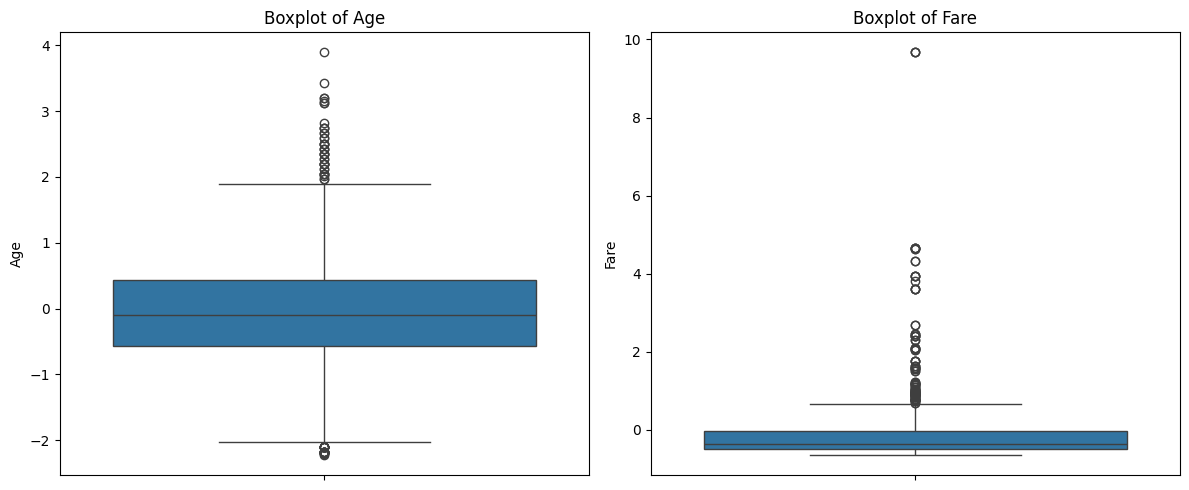


Dataset Shape After Removing Outliers:
(718, 11)

Final Cleaned Dataset:

   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    1 -0.565736      1      0   
2                        Heikkinen, Miss. Laina    0 -0.258337      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.433312      1      0   
4                      Allen, Mr. William Henry    1  0.433312      0      0   
5                              Moran, Mr. James    1 -0.104637      0      0   

             Ticket      Fare  Embarked  
0         A/5 21171 -0.502445         2  
2  STON/O2. 3101282 -0.488854         2  
3            113803  0.420730         2  
4            373450 -0.486337         2  
5            3308

In [3]:
# ============================================
# Task 1: Data Cleaning & Preprocessing
# Dataset Used: Titanic Dataset
# Tools: Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn
# ============================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ============================================
# Step 2: Load Dataset
# ============================================

# Download Titanic dataset from:
# https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

df = pd.read_csv("titanic.csv")

# Display first 5 rows
print("First 5 Rows:\n")
print(df.head())

# ============================================
# Step 3: Explore Dataset
# ============================================

print("\nDataset Information:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())

# ============================================
# Step 4: Handle Missing Values
# ============================================

# Fill Age missing values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked missing values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column because too many missing values
df.drop('Cabin', axis=1, inplace=True)

# Drop remaining missing rows
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

# ============================================
# Step 5: Convert Categorical Data into Numerical
# ============================================

# Label Encoding
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print("\nEncoded Dataset:\n")
print(df.head())

# ============================================
# Step 6: Feature Scaling
# ============================================

# Select numerical columns
numerical_cols = ['Age', 'Fare']

# Standardization
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nScaled Features:\n")
print(df[numerical_cols].head())

# ============================================
# Step 7: Detect Outliers Using Boxplot
# ============================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title("Boxplot of Age")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'])
plt.title("Boxplot of Fare")

plt.tight_layout()
plt.show()

# ============================================
# Step 8: Remove Outliers Using IQR Method
# ============================================

def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    return data[(data[column] >= lower_limit) & (data[column] <= upper_limit)]

# Remove outliers from Age and Fare
df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Fare')

print("\nDataset Shape After Removing Outliers:")
print(df.shape)

# ============================================
# Step 9: Final Cleaned Dataset
# ============================================

print("\nFinal Cleaned Dataset:\n")
print(df.head())

# Save cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_titanic.csv'")
# END OF TASK